In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("Aluminium Historical Data.csv")
df.head()

,Date,Price
0,2020-01-13,1798.0
1,2020-01-14,1809.0
2,2020-01-15,1801.0
3,2020-01-16,1812.0
4,2020-01-17,1805.0


In [ ]:
df.tail()

,Date,Price
1882,2025-03-09,2608.05
1883,2025-03-10,2608.05
1884,2025-03-11,2608.05
1885,2025-03-12,2608.05
1886,2025-03-13,2608.05


In [ ]:
all_business_days = pd.date_range(start='2020-01-02', end=pd.to_datetime("today"), freq='B')
print(all_business_days)

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2025-04-10', '2025-04-11', '2025-04-14', '2025-04-15',
               '2025-04-16', '2025-04-17', '2025-04-18', '2025-04-21',
               '2025-04-22', '2025-04-23'],
              dtype='datetime64[ns]', length=1385, freq='B')


In [ ]:
df1 = df.iloc[:,[0,1]]
print(df1.head())

         Date   Price
0  2020-01-13  1798.0
1  2020-01-14  1809.0
2  2020-01-15  1801.0
3  2020-01-16  1812.0
4  2020-01-17  1805.0


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1887 entries, 0 to 1886
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1887 non-null   object 
 1   Price   1887 non-null   float64
dtypes: float64(1), object(1)
memory usage: 29.6+ KB


In [ ]:
import pandas as pd

df2 = df1.copy()

def parse_dates(date):
    for fmt in ("%Y-%m-%d", "%d-%m-%Y", "%d/%m/%Y"):
        try:
            return pd.to_datetime(date, format=fmt)
        except (ValueError, TypeError):
            pass
    return pd.NaT  # Correct indentation here

df1["Date"] = df1["Date"].apply(parse_dates)  # Fixed quotes


In [ ]:

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1887 entries, 0 to 1886
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1887 non-null   datetime64[ns]
 1   Price   1887 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 29.6 KB


In [ ]:
merged_df1 = df1.copy()

In [ ]:

################## adding misssing dates #############



start_date_row = merged_df1[merged_df1["Date"] == merged_df1["Date"].min()]
end_date_row = merged_df1[merged_df1["Date"] == merged_df1["Date"].max()]
# Generate full range of business days
start_date = merged_df1["Date"].min()
end_date = merged_df1["Date"].max()
full_business_days = pd.date_range(start=start_date, end=end_date, freq="B")  # 'B' means business days

# Reindex DataFrame to include missing business days
df_full = pd.DataFrame({"Date": full_business_days})
df_merged = df_full.merge(merged_df1, on="Date", how="left")  # Merge to keep all business days

df_merged["Is_Non_Business_Day"] = df_merged["Date"].dt.weekday >= 5  # Saturday=5, Sunday=6

# Filter only non-business day rows
non_business_days = df_merged[df_merged["Is_Non_Business_Day"]]

# Display the results
if not non_business_days.empty:
    print("Non-Business Days Found:")
    print(non_business_days[["Date"]])
else:
    print("All dates are business days!")


df_merged1 = df_merged.drop("Is_Non_Business_Day", axis=1)
df_merged1.info()

All dates are business days!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1349 non-null   datetime64[ns]
 1   Price   1349 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 21.2 KB


In [ ]:
merged_df1 = merged_df1.ffill()


In [ ]:
merged_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1887 entries, 0 to 1886
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1887 non-null   datetime64[ns]
 1   Price   1887 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 29.6 KB


In [ ]:
# Remove commas and convert to numeric
merged_df1['Price'] = merged_df1['Price'].replace(',', '', regex=True).astype(float)

# Now compute the mean and median
mean_price = merged_df1['Price'].mean()
median_price = merged_df1['Price'].median()
mode_price = merged_df1['Price'].mode()

print("Mean Price:", mean_price)
print("Median Price:", median_price)
print("Mode price:", mode_price)

Mean Price: 2349.804451510334
Median Price: 2370.0
Mode price: 0    2337.0
Name: Price, dtype: float64


In [ ]:
variance = merged_df1['Price'].var()
print("Variance:", variance)


std_dev = merged_df1['Price'].std()
print("Standard Deviation:", std_dev)


skewness = merged_df1['Price'].skew()
print("Skewness:", skewness)


kurtosis = merged_df1['Price'].kurtosis()
print("Kurtosis:", kurtosis)



Variance: 170754.5732410436
Standard Deviation: 413.2246038670055
Skewness: 0.10743069217070753
Kurtosis: 0.38198802093025463


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

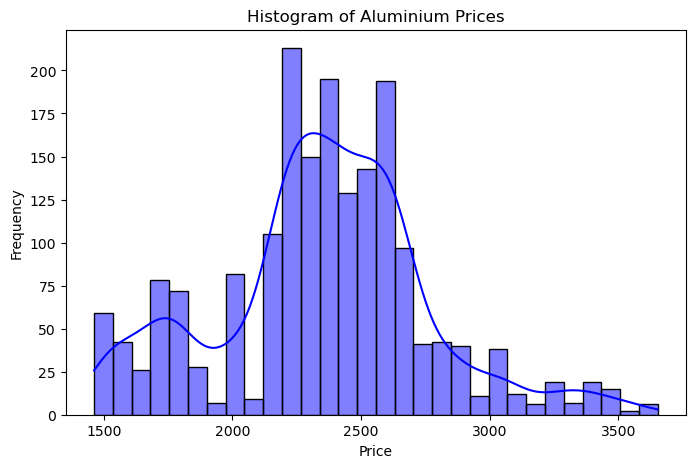

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True, color='blue')  # KDE adds a smooth curve
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Histogram of Aluminium Prices")
plt.show()


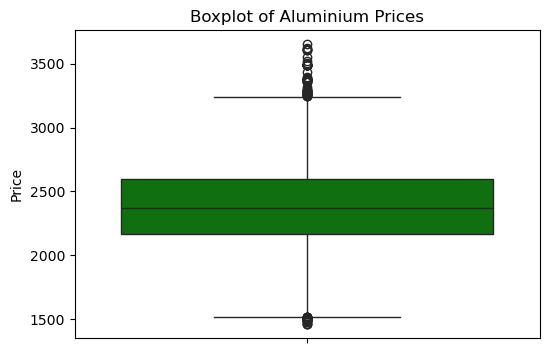

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Price'], color='green')
plt.ylabel("Price")
plt.title("Boxplot of Aluminium Prices")
plt.show()


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("Aluminium Historical Data.csv")

# Inspect the first few rows
print(df.head())

# Convert 'Date' column to datetime format, handling mixed formats
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

# Generate a complete range of business days
all_business_days = pd.date_range(start='2020-01-01', end=pd.to_datetime("today"), freq='B')

# Create a new DataFrame with all business days
full_df = pd.DataFrame({'Date': all_business_days})

# Merge with the original dataset
df_filled = full_df.merge(df, on='Date', how='left')

# Save the updated dataset
df_filled.to_csv("Aluminium_Historical_Data_Filled.csv", index=False)

print("Missing dates added, and file saved as 'Aluminium_Historical_Data_Filled.csv'")




         Date   Price
0  2020-01-13  1798.0
1  2020-01-14  1809.0
2  2020-01-15  1801.0
3  2020-01-16  1812.0
4  2020-01-17  1805.0
Missing dates added, and file saved as 'Aluminium_Historical_Data_Filled.csv'


C:\Users\vamsi\AppData\Local\Temp\ipykernel_17416\3582582477.py:10: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)


In [ ]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1386 non-null   datetime64[ns]
 1   Price   1349 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 21.8 KB


In [ ]:

# after outliers replace

dd = pd.read_csv("Aluminium_Historical_Data_Interpolated.csv")
dd

,Date,Price
0,2020-01-13,1798.00
1,2020-01-14,1809.00
2,2020-01-15,1801.00
3,2020-01-16,1812.00
4,2020-01-17,1805.00
...,...,...
1882,2025-03-09,2608.05
1883,2025-03-10,2608.05
1884,2025-03-11,2608.05
1885,2025-03-12,2608.05


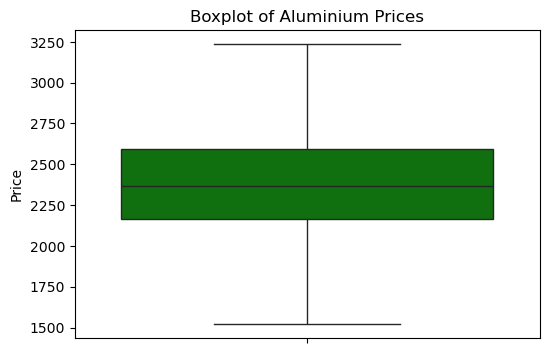

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=dd['Price'], color='green')
plt.ylabel("Price")
plt.title("Boxplot of Aluminium Prices")
plt.show()

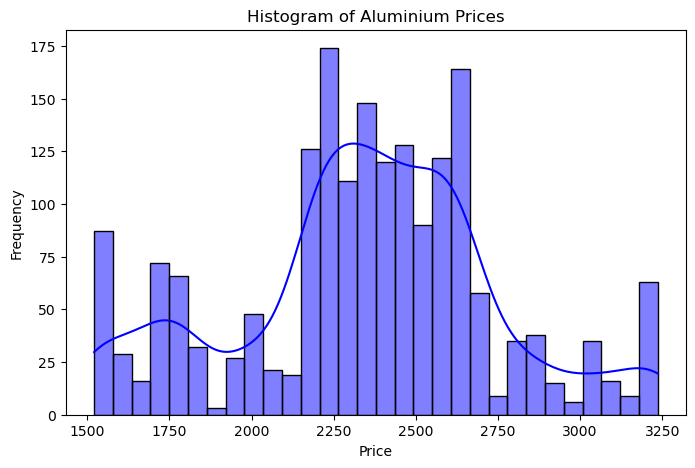

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(dd['Price'], bins=30, kde=True, color='blue')  # KDE adds a smooth curve
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Histogram of Aluminium Prices")
plt.show()

C:\Users\vamsi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Mean Absolute Error (MAE): 286.2888227513228
Root Mean Squared Error (RMSE): 315.4719131913843
        Date  Actual Price  Predicted Price
0 2024-03-01        2228.0         2280.000
1 2024-03-02        2228.0         2280.000
2 2024-03-03        2228.0         2280.000
3 2024-03-04        2228.0         2279.455
4 2024-03-05        2228.0         2279.455
Future Price Predictions:
         Date  Predicted Price
0  2025-03-14         2236.835
1  2025-03-15         2221.845
2  2025-03-16         2219.650
3  2025-03-17         2202.655
4  2025-03-18         2200.955
5  2025-03-19         2205.230
6  2025-03-20         2201.205
7  2025-03-21         2197.715
8  2025-03-22         2190.020
9  2025-03-23         2185.045
10 2025-03-24         2193.110
11 2025-03-25         2197.245
12 2025-03-26         2194.825
13 2025-03-27         2204.845
14 2025-03-28         2208.245
15 2025-03-29         2224.315
16 2025-03-30         2226.060
17 2025-03-31         2220.960
18 2025-04-01         2279

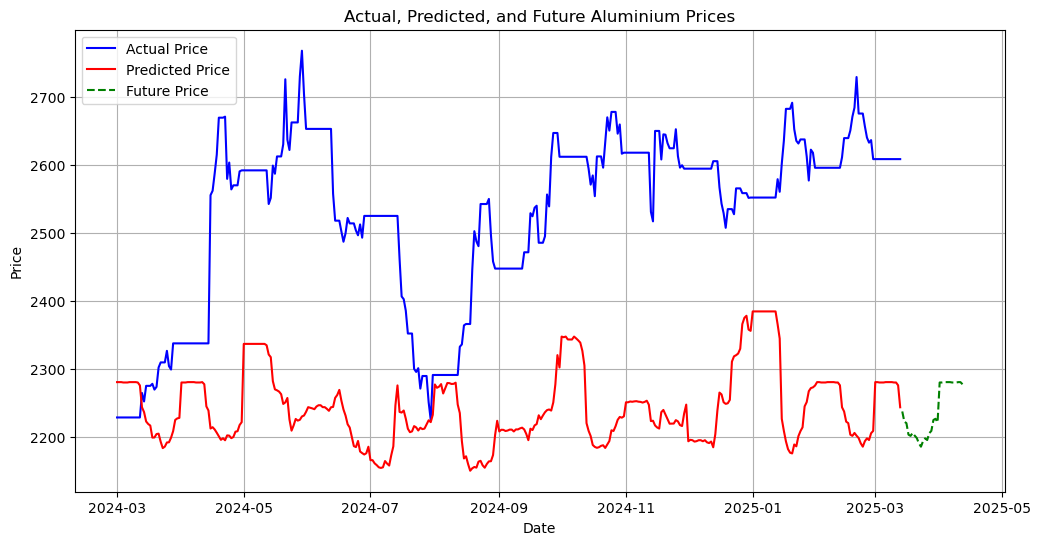

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load dataset
file_path = "Aluminium_Historical_Data_Interpolated.csv"
df = pd.read_csv(file_path)

# Convert Date column to datetime and extract features
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

# Define features and target
X = df[["Year", "Month", "Day", "DayOfWeek"]]
y = df["Price"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Create a DataFrame to store actual vs predicted prices
predictions_df = pd.DataFrame({
    "Date": df["Date"].iloc[-len(y_test):].values,
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

# Display the first few predicted values
print(predictions_df.head())

# Generate future dates for prediction
future_dates = pd.date_range(start=df["Date"].max() + pd.Timedelta(days=1), periods=30)
future_features = pd.DataFrame({
    "Year": future_dates.year,
    "Month": future_dates.month,
    "Day": future_dates.day,
    "DayOfWeek": future_dates.dayofweek
})

# Predict future prices
future_prices = model.predict(future_features)

# Create DataFrame for future predictions
future_df = pd.DataFrame({"Date": future_dates, "Predicted Price": future_prices})
print("Future Price Predictions:")
print(future_df)

# Plot actual, predicted, and future prices
plt.figure(figsize=(12, 6))
plt.plot(df["Date"].iloc[-len(y_test):], y_test, label="Actual Price", color='blue')
plt.plot(df["Date"].iloc[-len(y_test):], y_pred, label="Predicted Price", color='red')
plt.plot(future_df["Date"], future_df["Predicted Price"], label="Future Price", color='green', linestyle='dashed')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Actual, Predicted, and Future Aluminium Prices")
plt.legend()
plt.grid()
plt.show()

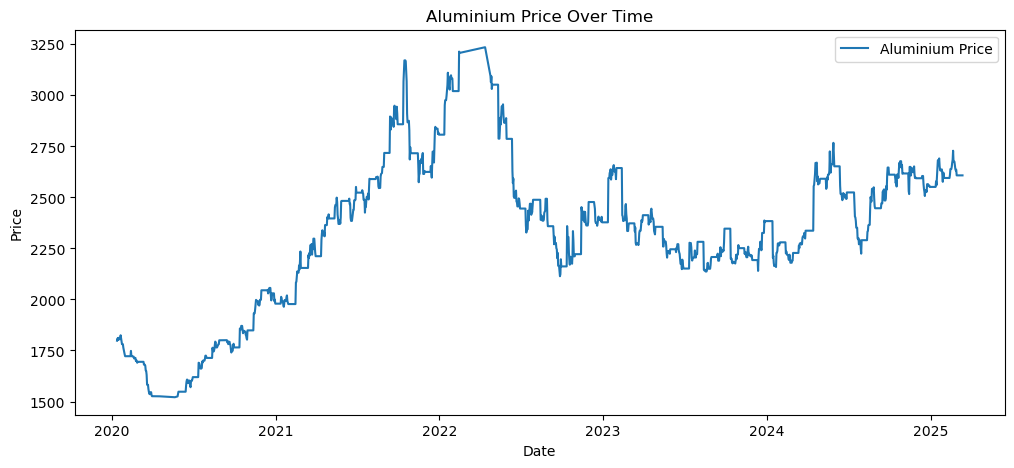

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 1887
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -8917.682
Date:                Wed, 23 Apr 2025   AIC                          17845.363
Time:                        10:18:25   BIC                          17873.074
Sample:                    01-13-2020   HQIC                         17855.568
                         - 03-13-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2368      0.007    173.510      0.000       1.223       1.251
ar.L2         -0.9740      0.007   -142.056      0.000      -0.987      -0.961
ma.L1         -1.2578      0.004   -325.579      0.0

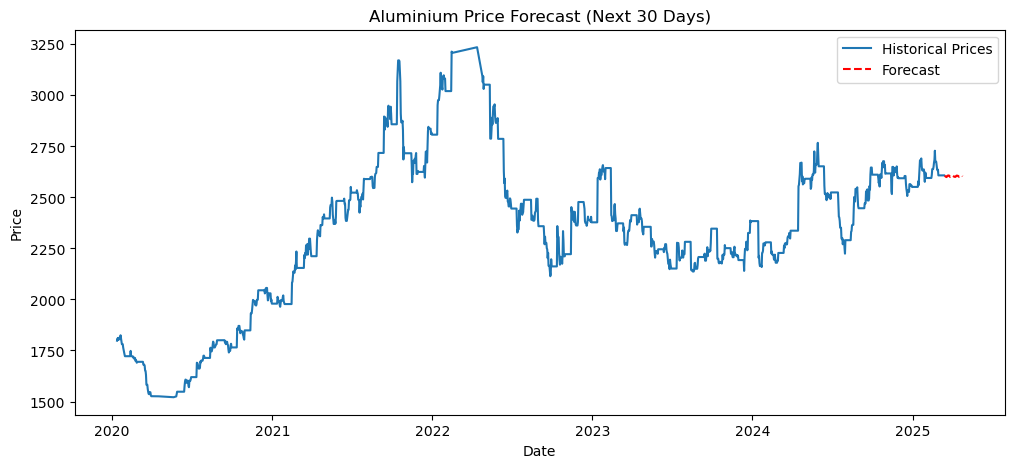

         Date  Predicted Price
0  2025-03-14      2605.699774
1  2025-03-17      2602.020208
2  2025-03-18      2599.758730
3  2025-03-19      2600.545915
4  2025-03-20      2603.722258
5  2025-03-21      2606.883852
6  2025-03-24      2607.700048
7  2025-03-25      2605.629937
8  2025-03-26      2602.274706
9  2025-03-27      2600.141506
10 2025-03-28      2600.771421
11 2025-03-31      2603.628311
12 2025-04-01      2606.548008
13 2025-04-02      2607.376203
14 2025-04-03      2605.556547
15 2025-04-04      2602.499383
16 2025-04-07      2600.490860
17 2025-04-08      2600.984640
18 2025-04-09      2603.551722
19 2025-04-10      2606.245601
20 2025-04-11      2607.076801
21 2025-04-14      2605.480821
22 2025-04-15      2602.697360
23 2025-04-16      2600.809470
24 2025-04-17      2601.185842
25 2025-04-18      2603.490218
26 2025-04-21      2605.973555
27 2025-04-22      2606.800256
28 2025-04-23      2605.403789
29 2025-04-24      2602.871459


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Load the dataset
df = pd.read_csv("Aluminium_Historical_Data_Interpolated.csv")

# Convert Date column to datetime format and set as index
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

# Plot the time series data
plt.figure(figsize=(12, 5))
plt.plot(df["Price"], label="Aluminium Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Aluminium Price Over Time")
plt.legend()
plt.show()

# Ignore convergence warnings
warnings.filterwarnings("ignore")

# Fit an ARIMA model (p=2, d=1, q=2)
model = ARIMA(df["Price"], order=(2,1,2))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

# Forecast the next 30 days
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)
forecast_dates = pd.date_range(df.index[-1], periods=forecast_steps+1, freq='B')[1:]
forecast_df = pd.DataFrame({"Date": forecast_dates, "Predicted Price": forecast.values})

# Save predicted prices to CSV
forecast_df.to_csv("Predicted_Aluminium_Prices.csv", index=False)

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Price"], label="Historical Prices")
plt.plot(forecast_df["Date"], forecast_df["Predicted Price"], label="Forecast", linestyle='dashed', color='red')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Aluminium Price Forecast (Next 30 Days)")
plt.legend()
plt.show()

# Display predicted prices
print(forecast_df)

MAE: 333.39822952835647, RMSE: 357.69455280227027
         Date  Predicted Price
0  2025-03-13      2192.083252
1  2025-03-14      2192.083252
2  2025-03-15      2192.083252
3  2025-03-16      2192.083252
4  2025-03-17      2192.083252
5  2025-03-18      2192.083252
6  2025-03-19      2192.083252
7  2025-03-20      2192.083252
8  2025-03-21      2192.083252
9  2025-03-22      2192.083252
10 2025-03-23      2192.083252
11 2025-03-24      2192.083252
12 2025-03-25      2192.083252
13 2025-03-26      2192.083252
14 2025-03-27      2192.083252
15 2025-03-28      2192.083252
16 2025-03-29      2192.083252
17 2025-03-30      2192.083252
18 2025-03-31      2192.083252
19 2025-04-01      2192.083252
20 2025-04-02      2192.083252
21 2025-04-03      2192.083252
22 2025-04-04      2192.083252
23 2025-04-05      2192.083252
24 2025-04-06      2192.083252
25 2025-04-07      2192.083252
26 2025-04-08      2192.083252
27 2025-04-09      2192.083252
28 2025-04-10      2192.083252
29 2025-04-11      2

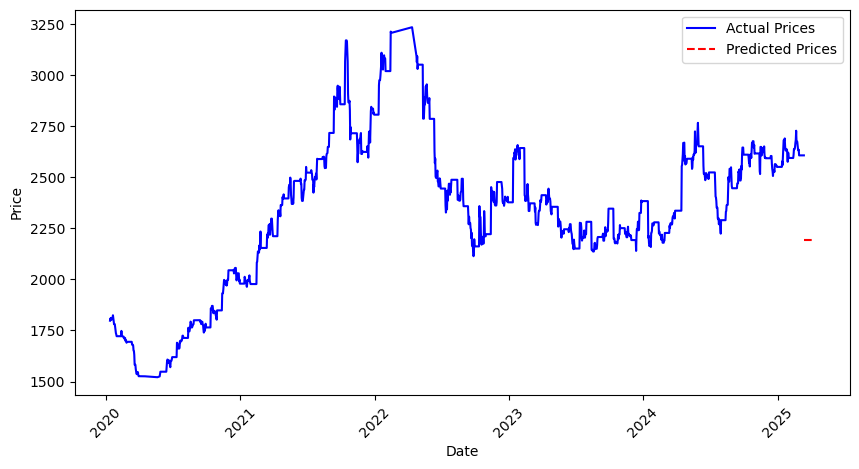

In [ ]:
#XGBoost Regressor


import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
file_path = "Aluminium_Historical_Data_Interpolated.csv"
df = pd.read_csv(file_path)

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')  # Ensure chronological order

# Set features and target variable
df['Days_Since_Start'] = (df['Date'] - df['Date'].min()).dt.days  # Convert date to numerical values
features = ['Days_Since_Start']  # You can add more features if available
target = 'Price'  # Adjust column name if necessary

X = df[features]
y = df[target]

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost model
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, objective='reg:squarederror')
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae}, RMSE: {rmse}")

# Future Prediction (Next 30 Days)
future_dates = pd.date_range(start=df['Date'].max(), periods=30, freq='D')  # Generate next 30 days
future_days_since_start = (future_dates - df['Date'].min()).days.to_numpy().reshape(-1, 1)  # Convert to numerical format
future_days_scaled = scaler.transform(future_days_since_start)  # Apply same scaling

future_prices = model.predict(future_days_scaled)

# Create a DataFrame for future predictions
future_df = pd.DataFrame({'Date': future_dates, 'Predicted Price': future_prices})
print(future_df)

# Plot Results
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Price'], label="Actual Prices", color='blue')
plt.plot(future_dates, future_prices, label="Predicted Prices", color='red', linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Mean Absolute Error: 13.387183908846271
Mean Squared Error: 561.2825177950606
Root Mean Squared Error: 23.691401769314126


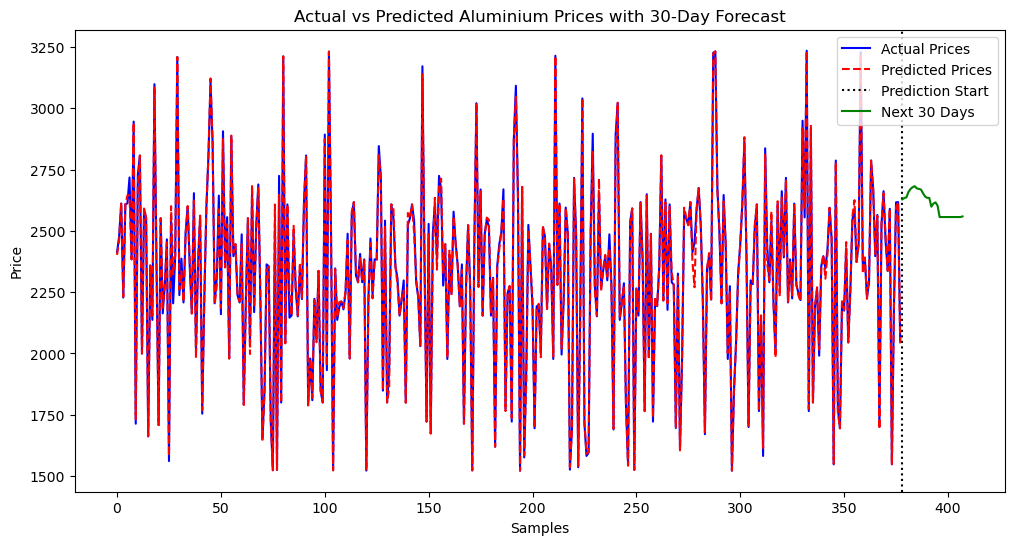

    Day  Month  Year  Predicted Price
0    14      3  2025        2628.4440
1    15      3  2025        2634.3425
2    16      3  2025        2636.6465
3    17      3  2025        2659.1685
4    18      3  2025        2671.2510
5    19      3  2025        2678.2950
6    20      3  2025        2682.4795
7    21      3  2025        2673.4065
8    22      3  2025        2671.3325
9    23      3  2025        2668.7895
10   24      3  2025        2653.6715
11   25      3  2025        2639.8285
12   26      3  2025        2634.9690
13   27      3  2025        2634.5470
14   28      3  2025        2598.8650
15   29      3  2025        2611.5520
16   30      3  2025        2616.3010
17   31      3  2025        2603.0005
18    1      4  2025        2556.4230
19    2      4  2025        2556.5505
20    3      4  2025        2556.5505
21    4      4  2025        2556.5505
22    5      4  2025        2556.5505
23    6      4  2025        2556.5505
24    7      4  2025        2556.5505
25    8     

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import timedelta

# Load data
df = pd.read_csv("Aluminium_Historical_Data_Interpolated.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

# Extract day, month, and year as features
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Store the last available date before dropping
last_date = df['Date'].iloc[-1]

# Drop original Date column
df.drop(columns=['Date'], inplace=True)

# Prepare features and target
X = df[['Day', 'Month', 'Year']]
y = df['Price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

# Generate next 30 days
future_dates = [last_date + timedelta(days=i) for i in range(1, 31)]  # Next 30 days

# Create dataframe for future dates
future_df = pd.DataFrame({
    'Day': [date.day for date in future_dates],
    'Month': [date.month for date in future_dates],
    'Year': [date.year for date in future_dates]
})

# Predict future prices
future_prices = model.predict(future_df)

# Plot actual vs predicted prices
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Prices', color='blue')
plt.plot(y_pred, label='Predicted Prices', color='red', linestyle='dashed')
plt.axvline(x=len(y_test), color='black', linestyle='dotted', label="Prediction Start")
plt.plot(range(len(y_test), len(y_test) + 30), future_prices, label="Next 30 Days", color='green')

plt.xlabel("Samples")
plt.ylabel("Price")
plt.title("Actual vs Predicted Aluminium Prices with 30-Day Forecast")
plt.legend()
plt.show()

# Print next 30 days predicted prices
future_df['Predicted Price'] = future_prices
print(future_df)